# 📊 50 Startups: Exploratory Data Analysis (EDA)
This notebook provides a high-level business overview of what the historical data tells us about startup financial success.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization style
sns.set_theme(style="whitegrid")

## 1. Data Loading & High-Level Overview
First, we load the dataset and take a look at the key metrics.

In [2]:
# Load the dataset
df = pd.read_csv("50_Startups.csv")

# Display the first 5 rows
display(df.head())

# Display basic KPI metrics
avg_profit = df['Profit'].mean()
max_profit = df['Profit'].max()
top_state = df.groupby('State')['Profit'].mean().idxmax()

print(f"💰 Average Startup Profit: ${avg_profit:,.0f}")
print(f"🏆 Highest Profit Recorded: ${max_profit:,.0f}")
print(f"🌎 Top Performing Market: {top_state}")

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


💰 Average Startup Profit: $112,013
🏆 Highest Profit Recorded: $192,262
🌎 Top Performing Market: Florida


## 2. Which Department Drives Profit?
To understand where a startup should allocate its budget, we look at the correlation between different spending categories and the final profit.

/var/folders/16/__2mqr3j1gsd1bbrntqp_qv00000gn/T/ipykernel_11222/2172187510.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_corr['Profit'], y=profit_corr.index, palette="viridis")


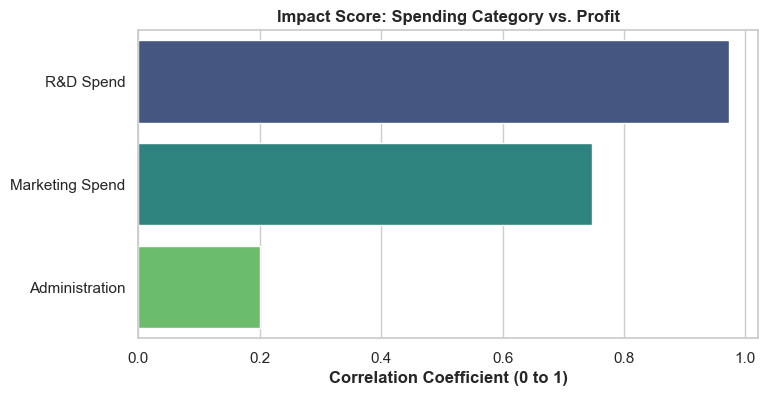

In [3]:
# Calculate correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()

# Isolate the correlation with Profit and sort it
profit_corr = corr_matrix[['Profit']].drop('Profit').sort_values(by='Profit', ascending=False)

# Plotting the Impact Score (Correlation with Profit)
plt.figure(figsize=(8, 4))
sns.barplot(x=profit_corr['Profit'], y=profit_corr.index, palette="viridis")
plt.title("Impact Score: Spending Category vs. Profit", fontweight='bold')
plt.xlabel("Correlation Coefficient (0 to 1)", fontweight='bold')
plt.ylabel("")
plt.show()

## 2b. Correlation Heatmap
While the bar chart above shows the direct impact on profit, a correlation heatmap gives us the exact mathematical correlation (from -1 to 1) between every single numerical variable in our dataset.

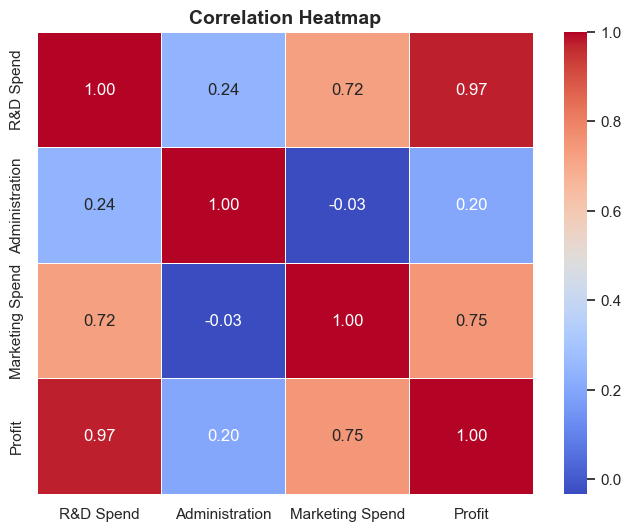

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontweight='bold', fontsize=14)
plt.show()

## 3. The R&D Effect: Visualizing the Growth
Since R&D is the strongest predictor of profit, let's plot every startup's R&D budget against their final profit to visualize this trend.

**💡 Business Insight:** **R&D Spend** is the undisputed engine of profit (Correlation ~0.97). Marketing provides a moderate boost, while Administration spending has almost zero relationship with financial success.

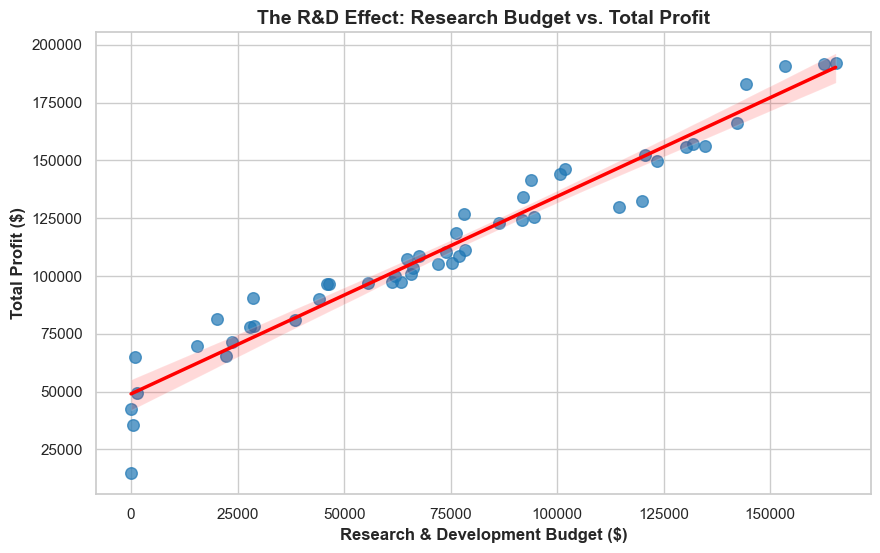

In [5]:
plt.figure(figsize=(10, 6))

# sns.regplot draws a scatter plot with a built-in linear trendline
sns.regplot(x='R&D Spend', y='Profit', data=df,
            scatter_kws={'alpha':0.7, 'color':'#1f77b4', 's': 70},
            line_kws={'color':'red', 'lw': 2.5})

plt.title("The R&D Effect: Research Budget vs. Total Profit", fontsize=14, fontweight='bold')
plt.xlabel("Research & Development Budget ($)", fontweight='bold', fontsize=12)
plt.ylabel("Total Profit ($)", fontweight='bold', fontsize=12)

plt.show()

**💡 Business Insight:** The tight clustering of dots around the red trendline proves a highly reliable linear relationship: more R&D directly equals more Profit.


## 4. Regional Performance
Does the state where the startup operates significantly affect its profit?

/var/folders/16/__2mqr3j1gsd1bbrntqp_qv00000gn/T/ipykernel_11222/4247402769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Profit', data=df, order=state_order, palette="Set2", errorbar=None)


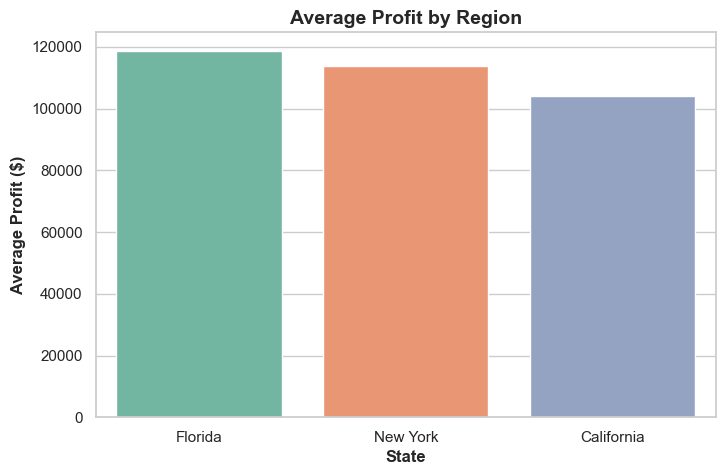

In [6]:
plt.figure(figsize=(8, 5))

# Calculate average profit per state to order the bars
state_order = df.groupby('State')['Profit'].mean().sort_values(ascending=False).index

# Plot average profit by state
sns.barplot(x='State', y='Profit', data=df, order=state_order, palette="Set2", errorbar=None)

plt.title("Average Profit by Region", fontsize=14, fontweight='bold')
plt.ylabel("Average Profit ($)", fontweight='bold')
plt.xlabel("State", fontweight='bold')

plt.show()

## 4b. Profit Distribution by Region (Boxplot)
While averages are helpful, a boxplot shows us the *range* and *outliers* of profits in each state.

/var/folders/16/__2mqr3j1gsd1bbrntqp_qv00000gn/T/ipykernel_11222/2790794525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='State', y='Profit', data=df, palette="Set2")


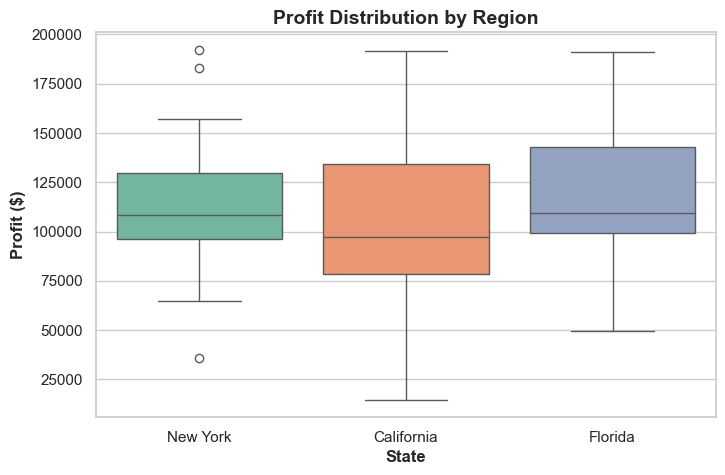

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='State', y='Profit', data=df, palette="Set2")
plt.title("Profit Distribution by Region", fontsize=14, fontweight='bold')
plt.ylabel("Profit ($)", fontweight='bold')
plt.xlabel("State", fontweight='bold')
plt.show()

**💡 Business Insight:** Startups in **Florida** and **New York** show slightly higher average profits than California, though the difference is minimal compared to the impact of R&D spending.

## 5. Deep Dive Analysis: The Zero-Spend Anomalies
What happens when a startup completely cuts its R&D or Marketing budget? Let's look at the actual profit comparisons from the dataset.

/var/folders/16/__2mqr3j1gsd1bbrntqp_qv00000gn/T/ipykernel_11222/613095358.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['$0 R&D Spend', 'Invested in R&D'], y=[rd_zero, rd_nonzero], palette=['#d62728', '#2ca02c'], ax=axes[0])
/var/folders/16/__2mqr3j1gsd1bbrntqp_qv00000gn/T/ipykernel_11222/613095358.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['$0 Marketing', 'Invested in Marketing'], y=[mkt_zero, mkt_nonzero], palette=['#ff7f0e', '#1f77b4'], ax=axes[1])


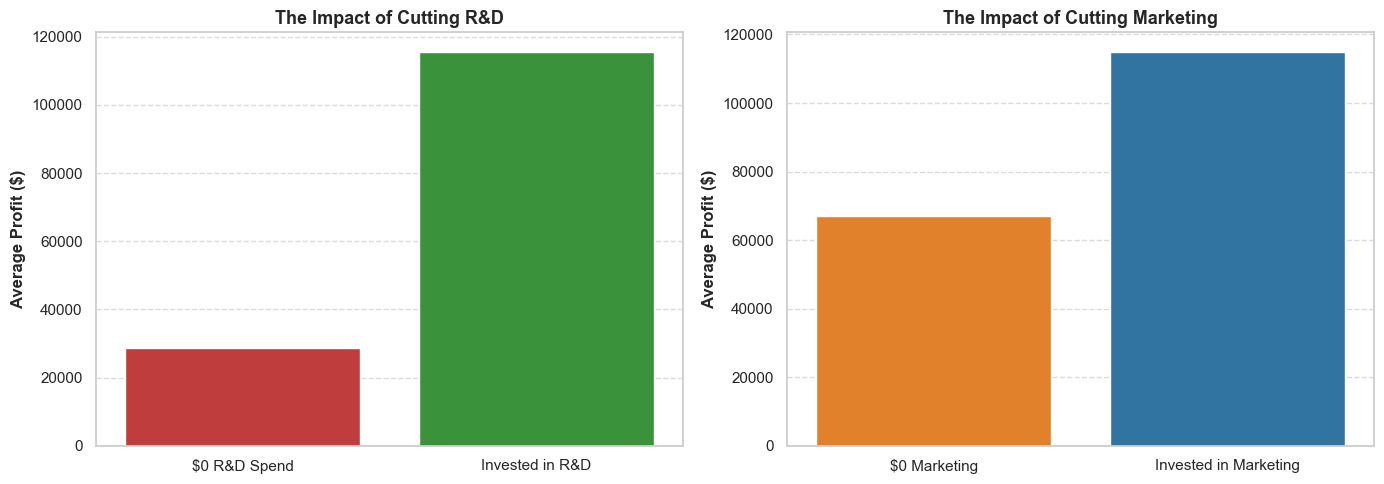

In [8]:
# Calculate means for R&D
rd_zero = df[df['R&D Spend'] == 0]['Profit'].mean()
rd_nonzero = df[df['R&D Spend'] > 0]['Profit'].mean()

# Calculate means for Marketing
mkt_zero = df[df['Marketing Spend'] == 0]['Profit'].mean()
mkt_nonzero = df[df['Marketing Spend'] > 0]['Profit'].mean()

# Create subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R&D Impact
sns.barplot(x=['$0 R&D Spend', 'Invested in R&D'], y=[rd_zero, rd_nonzero], palette=['#d62728', '#2ca02c'], ax=axes[0])
axes[0].set_ylabel("Average Profit ($)", fontweight='bold')
axes[0].set_title("The Impact of Cutting R&D", fontweight='bold', fontsize=13)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Marketing Impact
sns.barplot(x=['$0 Marketing', 'Invested in Marketing'], y=[mkt_zero, mkt_nonzero], palette=['#ff7f0e', '#1f77b4'], ax=axes[1])
axes[1].set_ylabel("Average Profit ($)", fontweight='bold')
axes[1].set_title("The Impact of Cutting Marketing", fontweight='bold', fontsize=13)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 6. Machine Learning Model & Statistical Evidence
Now, we train a Multiple Linear Regression model and plot the statistical evidence to prove its accuracy and the actual dollar contribution of each department.

R² Score: 0.8987
Mean Absolute Error (MAE): $6,961
Root Mean Squared Error (RMSE): $9,056



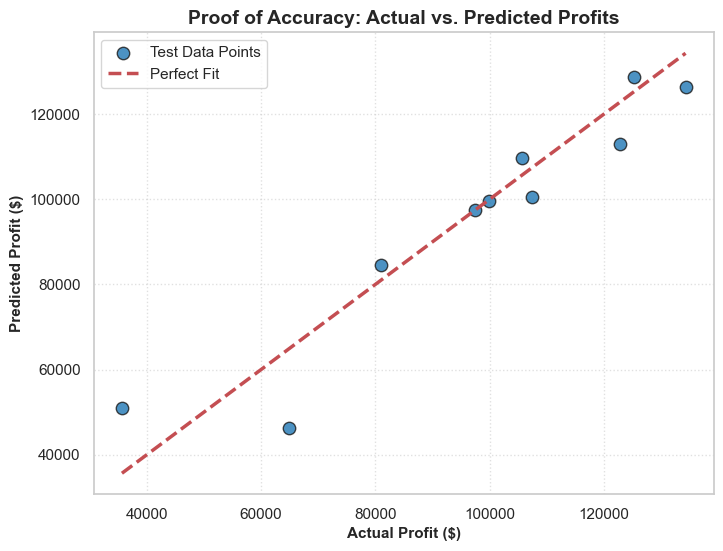

/var/folders/16/__2mqr3j1gsd1bbrntqp_qv00000gn/T/ipykernel_11222/2295630799.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average Contribution ($)', y='Department', data=contrib_df,


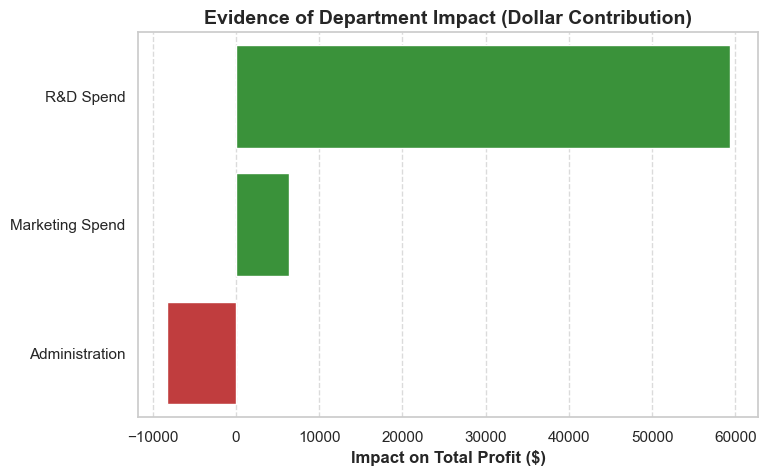

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Preprocessing: Convert 'State' to dummy variables
df_processed = pd.get_dummies(df, columns=['State'], drop_first=True)
X = df_processed.drop('Profit', axis=1)
y = df_processed['Profit']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions & Metrics
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.0f}\n")

# --- Plot 1: Actual vs Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='#1f77b4', alpha=0.8, edgecolors='k', s=80, label='Test Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Perfect Fit')
plt.xlabel('Actual Profit ($)', fontsize=11, fontweight='bold')
plt.ylabel('Predicted Profit ($)', fontsize=11, fontweight='bold')
plt.title('Proof of Accuracy: Actual vs. Predicted Profits', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# --- Plot 2: Evidence of Department Impact ---
features = X.columns
coefs = model.coef_
mean_values = X.mean()

contributions = []
for feature, coef in zip(features, coefs):
    if 'State' not in feature:
        contributions.append({'Department': feature, 'Average Contribution ($)': coef * mean_values[feature]})

contrib_df = pd.DataFrame(contributions).sort_values(by='Average Contribution ($)', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Average Contribution ($)', y='Department', data=contrib_df,
            palette=['#2ca02c' if x > 0 else '#d62728' for x in contrib_df['Average Contribution ($)']])
plt.xlabel("Impact on Total Profit ($)", fontweight='bold')
plt.ylabel("")
plt.title("Evidence of Department Impact (Dollar Contribution)", fontsize=14, fontweight='bold')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

## 7. Advanced Error Analysis (Residuals)
To trust our model, we must verify that its mistakes (residuals) are random and normally distributed. If they are not, the model may be fundamentally flawed.

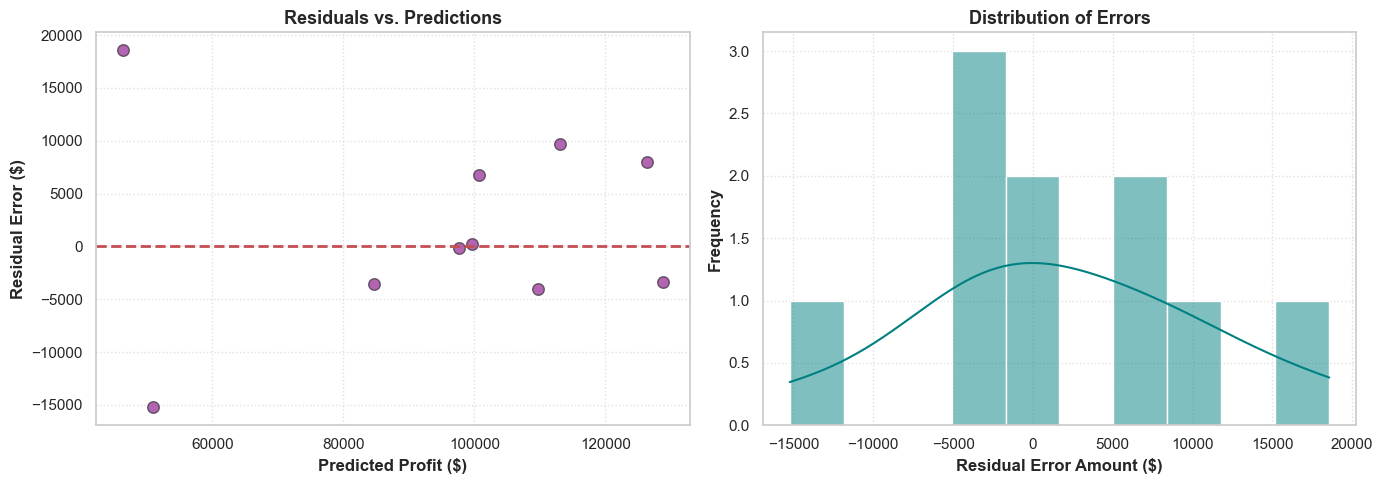

In [10]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Predictions
axes[0].scatter(y_pred, residuals, color='purple', alpha=0.6, edgecolors='k', s=70)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel("Predicted Profit ($)", fontweight='bold')
axes[0].set_ylabel("Residual Error ($)", fontweight='bold')
axes[0].set_title("Residuals vs. Predictions", fontweight='bold', fontsize=13)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Distribution of Errors
sns.histplot(residuals, kde=True, color='teal', bins=10, ax=axes[1])
axes[1].set_xlabel("Residual Error Amount ($)", fontweight='bold')
axes[1].set_ylabel("Frequency", fontweight='bold')
axes[1].set_title("Distribution of Errors", fontweight='bold', fontsize=13)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()